# Assumption Check

This notebook visualizes results from the Assumption Check analysis.

**Workflow:**
1. Run `python Assumption_Check.py` to generate data, train models, and compute MCODEC scores
2. This notebook loads and visualizes the results

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from scipy import stats

# Set up plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete!")

Setup complete!


## Load Results

**Note:** Run `python Assumption_Check.py` first if results don't exist.

In [2]:
# Load results for both scenarios
results = {}
scenarios = ['sc1', 'sc2']

for scenario in scenarios:
    scenario_dir = os.path.join('./results', f'Assumption_Check_{scenario}')
    
    # Load tau_observed
    tau_obs_path = os.path.join(scenario_dir, 'tau_observed.csv')
    if os.path.exists(tau_obs_path):
        tau_obs_df = pd.read_csv(tau_obs_path)
        tau_observed = tau_obs_df['tau_observed'].values[0]
    else:
        print(f"tau_observed not found for {scenario}")
        continue
    
    # Load tau samples
    tau_path = os.path.join(scenario_dir, 'tau_samples.csv')
    if os.path.exists(tau_path):
        tau_samples_df = pd.read_csv(tau_path)
        tau_samples = tau_samples_df['tau_value'].values
    else:
        print(f"Tau samples not found for {scenario}")
        continue
    
    # Load training data and singular values
    data_path = os.path.join('./data', f'Assumption_Check_{scenario}', 'train_data.csv')
    singular_values_path = os.path.join('./data', f'Assumption_Check_{scenario}', 'singular_values.csv')
    if os.path.exists(data_path):
        train_data = pd.read_csv(data_path)
        singular_values_df = pd.read_csv(singular_values_path)
        singular_values = singular_values_df['singular_value'].values
    else:
        print(f"Training data not found for {scenario}")
        train_data = None
    
    # Compute statistics
    num_larger_or_equal = np.sum(tau_samples >= tau_observed)
    p_value = (1 + num_larger_or_equal) / (len(tau_samples) + 1)
    
    results[scenario] = {
        'tau_observed': tau_observed,
        'tau_samples': tau_samples,
        'train_data': train_data,
        'singular_values': singular_values,
        'p_value': p_value,
        'num_larger_or_equal': num_larger_or_equal
    }
    
    print(f"\n{scenario.upper()} Results:")
    print(f"  τ_obs:   {tau_observed:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Decision: {'REJECT H0' if p_value <= 0.05 else 'FAIL TO REJECT H0'}")


SC1 Results:
  τ_obs:   0.345321
  P-value: 0.001996
  Decision: REJECT H0

SC2 Results:
  τ_obs:   0.013869
  P-value: 0.413174
  Decision: FAIL TO REJECT H0


## Visualization: Singular Values

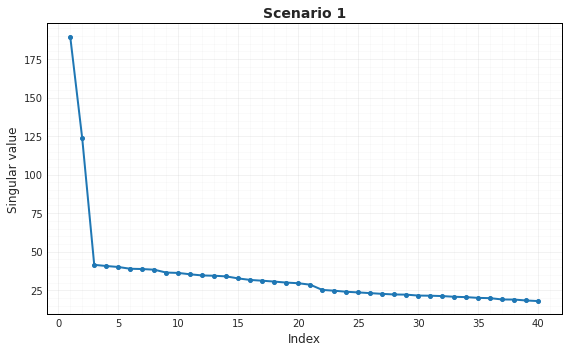

Figure saved to: results/sc1_singular_values.png


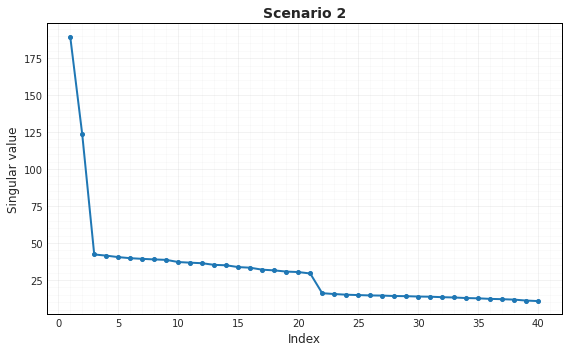

Figure saved to: results/sc2_singular_values.png


In [3]:

# Optional: match the same clean style you used before
plt.style.use("seaborn-whitegrid")  # if this errors, try "seaborn-whitegrid"

caption_map = {
    "sc1": "Scenario 1",
    "sc2": "Scenario 2",
    "scenario1": "Scenario 1",
    "scenario2": "Scenario 2",
    "scenario_1": "Scenario 1",
    "scenario_2": "Scenario 2",
    "Scenario 1": "Scenario 1",
    "Scenario 2": "Scenario 2",
}

os.makedirs("results", exist_ok=True)

for scenario in scenarios:
    if scenario not in results:
        continue
    if "singular_values" not in results[scenario] or results[scenario]["singular_values"] is None:
        print(f"No singular values found for {scenario}")
        continue

    svals = np.asarray(results[scenario]["singular_values"], dtype=float)
    x = np.arange(1, len(svals) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))

    # Line plot (separate figure per scenario)
    ax.plot(x, svals, marker="o", linewidth=2, markersize=4)

    # Labels / title
    ax.set_xlabel("Index", fontsize=12)
    ax.set_ylabel("Singular value", fontsize=12)
    ax.set_title(caption_map.get(scenario, str(scenario)), fontsize=14, fontweight="bold")

    # Grid + spines similar to your histogram style
    ax.grid(True, which="major", alpha=0.30)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

    plt.tight_layout()

    safe_name = str(scenario).replace(" ", "_").replace("/", "_")
    out_path = f"results/{safe_name}_singular_values.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure saved to: {out_path}")

## Visualization: MCODEC Score Distributions

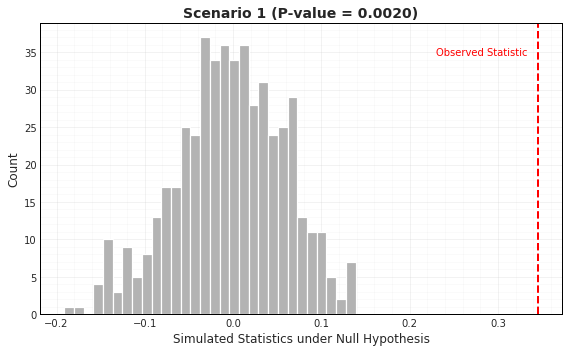

Figure saved to: results/sc1_MCODEC_score_distribution.png


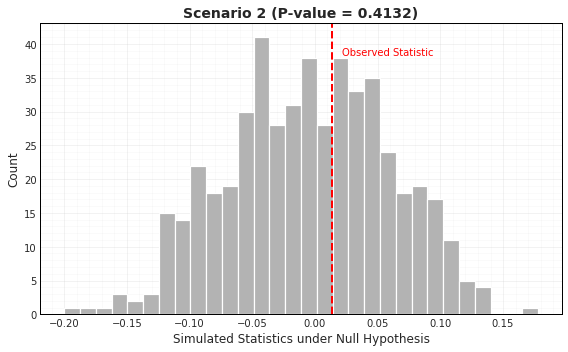

Figure saved to: results/sc2_MCODEC_score_distribution.png


In [4]:
# Make matplotlib look like your attached figure
plt.style.use("seaborn-whitegrid")  # if this errors, try: "seaborn-v0_8-whitegrid"

caption_map = {
    "sc1": "Scenario 1",
    "sc2": "Scenario 2",
    "scenario1": "Scenario 1",
    "scenario2": "Scenario 2",
    "scenario_1": "Scenario 1",
    "scenario_2": "Scenario 2",
    "Scenario 1": "Scenario 1",
    "Scenario 2": "Scenario 2",
}

for scenario in scenarios:
    if scenario not in results:
        continue

    tau_samples = results[scenario]["tau_samples"]
    tau_observed = results[scenario]["tau_observed"]
    p_value = results[scenario]["p_value"]

    fig, ax = plt.subplots(figsize=(8, 5))

    # Histogram: gray bars with white borders
    ax.hist(
        tau_samples,
        bins=30,
        color="0.7",
        edgecolor="white",
        linewidth=1.2
    )

    # Observed statistic line
    ax.axvline(tau_observed, color="red", linestyle="--", linewidth=2)

    # --- Place annotation depending on scenario ---
    ymax = ax.get_ylim()[1]
    if str(scenario).lower() in ["sc1", "scenario1", "scenario_1", "scenario 1"]:
        # Scenario 1: text LEFT of the line
        xytext = (-10, 0)
        ha = "right"
    else:
        # Scenario 2 (and anything else): text RIGHT of the line
        xytext = (10, 0)
        ha = "left"

    ax.annotate(
        "Observed Statistic",
        xy=(tau_observed, 0.90 * ymax),
        xytext=xytext,               # left/right offset in points
        textcoords="offset points",
        color="red",
        ha=ha,
        va="center",
        fontsize=10,
    )

    # Labels
    ax.set_xlabel("Simulated Statistics under Null Hypothesis", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)

    # Title with p-value
    title = f"{caption_map.get(scenario, str(scenario))} (P-value = {p_value:.4f})"
    ax.set_title(title, fontsize=14, fontweight="bold")

    # Grid
    ax.grid(True, which="major", alpha=0.30)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)

    # Spines
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

    plt.tight_layout()

    safe_name = str(scenario).replace(" ", "_").replace("/", "_")
    out_path = f"results/{safe_name}_MCODEC_score_distribution.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure saved to: {out_path}")

## Summary Statistics

In [5]:
# Detailed statistics for each scenario
for scenario in scenarios:
    if scenario not in results:
        continue
    
    print(f"\n{'='*70}")
    print(f"SCENARIO {scenario.upper()} - DETAILED STATISTICS")
    print(f"{'='*70}")
    
    tau_observed = results[scenario]['tau_observed']
    tau_samples = results[scenario]['tau_samples']
    p_value = results[scenario]['p_value']
    num_larger_or_equal = results[scenario]['num_larger_or_equal']
    
    print(f"\nConditional Independence Test: X1 ⊥ Y1 | Z1")
    print(f"  Observed statistic (τ_obs):    {tau_observed:.6f}")
    print(f"  P-value:                        {p_value:.6f}")
    print(f"  Number of MC samples:           {len(tau_samples)}")
    print(f"  # of τ^(d) ≥ τ_obs:             {num_larger_or_equal}")
    
    print(f"\nNull Distribution Statistics (τ^(d)):")
    print(f"  Mean:                           {np.mean(tau_samples):.6f}")
    print(f"  Std:                            {np.std(tau_samples):.6f}")
    print(f"  Min:                            {np.min(tau_samples):.6f}")
    print(f"  Max:                            {np.max(tau_samples):.6f}")
    print(f"  Median:                         {np.median(tau_samples):.6f}")
    
    print(f"\nDecision (α = 0.05):")
    if p_value <= 0.05:
        print(f"  → REJECT H0: Evidence against X1 ⊥ Y1 | Z1")
    else:
        print(f"  → FAIL TO REJECT H0: No evidence against X1 ⊥ Y1 | Z1")


SCENARIO SC1 - DETAILED STATISTICS

Conditional Independence Test: X1 ⊥ Y1 | Z1
  Observed statistic (τ_obs):    0.345321
  P-value:                        0.001996
  Number of MC samples:           500
  # of τ^(d) ≥ τ_obs:             0

Null Distribution Statistics (τ^(d)):
  Mean:                           -0.003522
  Std:                            0.061851
  Min:                            -0.191392
  Max:                            0.138694
  Median:                         -0.002561

Decision (α = 0.05):
  → REJECT H0: Evidence against X1 ⊥ Y1 | Z1

SCENARIO SC2 - DETAILED STATISTICS

Conditional Independence Test: X1 ⊥ Y1 | Z1
  Observed statistic (τ_obs):    0.013869
  P-value:                        0.413174
  Number of MC samples:           500
  # of τ^(d) ≥ τ_obs:             206

Null Distribution Statistics (τ^(d)):
  Mean:                           -0.005176
  Std:                            0.064651
  Min:                            -0.200025
  Max:                  